# 03 Model Experiments

Compare a seasonal-naive baseline, ANN, and DNN using chronological splits. Model performance will be measured with MAE, RMSE, and WAPE.

### Imports and configuration

In [28]:
from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DATA_DIR, MODEL_DIR, REPORT_DIR

In [29]:
RANDOM_SEED = 42
EXPECTED_STORE_COUNT = 10

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

FEATURE_PATHS = sorted(
    FEATURES_DATA_DIR.glob("store_id=*/features.parquet")
)

if len(FEATURE_PATHS) != EXPECTED_STORE_COUNT:
    raise FileNotFoundError(
        f"Expected {EXPECTED_STORE_COUNT} feature partitions in "
        f"{FEATURES_DATA_DIR}, but found {len(FEATURE_PATHS)}. "
        "Run: python -m src.data.pipeline --overwrite"
    )

STORE_IDS = tuple(
    path.parent.name.removeprefix("store_id=")
    for path in FEATURE_PATHS
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Feature partitions: {len(FEATURE_PATHS)}")
print(f"Stores: {', '.join(STORE_IDS)}")

Project root: D:\Repos\ML-StockPredict
Feature partitions: 10
Stores: CA_1, CA_2, CA_3, CA_4, TX_1, TX_2, TX_3, WI_1, WI_2, WI_3


### Define chronological split dates

The validation and test sets each cover 28 forecast-origin dates. A seven-day purge gap is placed before each set because `target_7d` contains demand from the following seven days. This prevents a training label from overlapping demand used in a later evaluation period.

In [30]:

TRAIN_END = pd.Timestamp("2016-03-06")

VAL_START = pd.Timestamp("2016-03-14")
VAL_END = pd.Timestamp("2016-04-10")

TEST_START = pd.Timestamp("2016-04-18")
TEST_END = pd.Timestamp("2016-05-15")

STORE_IDS = [
    "CA_1",
    "CA_2",
    "CA_3",
    "CA_4",
    "TX_1",
    "TX_2",
    "TX_3",
    "WI_1",
    "WI_2",
    "WI_3",
]

In [31]:
def get_split(df, split):
    dates = pd.to_datetime(df["date"])

    if split == "train":
        mask = dates <= TRAIN_END

    elif split == "val":
        mask = (
            (dates >= VAL_START)
            & (dates <= VAL_END)
        )

    elif split == "test":
        mask = (
            (dates >= TEST_START)
            & (dates <= TEST_END)
        )

    else:
        raise ValueError(
            "split must be train, val or test"
        )

    return df.loc[mask].copy()

In [32]:
df = pd.read_parquet(
    next(
        path
        for path in FEATURE_PATHS
        if path.parent.name == "store_id=CA_1"
    )
)

df["date"] = pd.to_datetime(df["date"])

train_df = get_split(df, "train")
val_df = get_split(df, "val")
test_df = get_split(df, "test")

print("Train:", train_df["date"].min(), train_df["date"].max())
print("Validation:", val_df["date"].min(), val_df["date"].max())
print("Test:", test_df["date"].min(), test_df["date"].max())

print("Train rows:", f"{len(train_df):,}")
print("Validation rows:", f"{len(val_df):,}")
print("Test rows:", f"{len(test_df):,}")

Train: 2011-02-26 00:00:00 2016-03-06 00:00:00
Validation: 2016-03-14 00:00:00 2016-04-10 00:00:00
Test: 2016-04-18 00:00:00 2016-05-15 00:00:00
Train rows: 4,468,127
Validation rows: 85,372
Test rows: 85,372


###  Establish the baseline

Predicted next 7-day sales=actual previous 7-day sales

In [33]:
y_true = val_df["target_7d"].to_numpy()
y_pred = val_df["sales_sum_7"].to_numpy()

In [34]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_true - y_pred

    mae = np.mean(
        np.abs(error)
    )

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    denominator = np.sum(
        np.abs(y_true)
    )

    wape = (
        np.sum(np.abs(error))
        / denominator
        * 100
        if denominator != 0
        else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
    }

In [35]:
baseline_metrics = regression_metrics(
    y_true,
    y_pred
)

print(baseline_metrics)

{'MAE': np.float64(4.175971044370519), 'RMSE': np.float64(8.63621626430888), 'WAPE': np.float64(39.72687916826851)}


### baseline per store

In [36]:
FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "features"

def store_file(store_id: str) -> Path:
    return (
        FEATURE_DIR
        / f"store_id={store_id}"
        / "features.parquet"
    )

In [37]:
baseline_results = []

overall_abs_error = 0.0
overall_squared_error = 0.0
overall_actual = 0.0
overall_n = 0

for store_id in STORE_IDS:

    print("Processing:", store_id)

    df = pd.read_parquet(
    FEATURE_DIR / f"store_id={store_id}" / "features.parquet",
    columns=[
        "date",
        "sales_sum_7",
        "target_7d",
    ],
    engine="pyarrow",
)

    df["date"] = pd.to_datetime(
        df["date"]
    )

    val = get_split(
        df,
        "val"
    )

    y_true = val[
        "target_7d"
    ].to_numpy()

    y_pred = val[
        "sales_sum_7"
    ].to_numpy()

    metrics = regression_metrics(
        y_true,
        y_pred
    )

    metrics["store_id"] = store_id

    baseline_results.append(
        metrics
    )

    errors = (
        y_true - y_pred
    )

    overall_abs_error += (
        np.abs(errors).sum()
    )

    overall_squared_error += (
        (errors ** 2).sum()
    )

    overall_actual += (
        np.abs(y_true).sum()
    )

    overall_n += len(y_true)

Processing: CA_1
Processing: CA_2
Processing: CA_3
Processing: CA_4
Processing: TX_1
Processing: TX_2
Processing: TX_3
Processing: WI_1
Processing: WI_2
Processing: WI_3


In [38]:
baseline_results_df = pd.DataFrame(
    baseline_results
)

display(
    baseline_results_df[
        [
            "store_id",
            "MAE",
            "RMSE",
            "WAPE",
        ]
    ]
)

,store_id,MAE,RMSE,WAPE
0,CA_1,4.1760,8.6362,39.7269
1,CA_2,4.3578,8.7133,44.1426
2,CA_3,5.1084,11.1648,34.7444
3,CA_4,2.9134,5.3885,48.3119
4,TX_1,3.3105,7.2608,43.4741
5,TX_2,3.6550,7.1739,39.5129
6,TX_3,3.6448,7.7077,41.5522
7,WI_1,3.6092,6.6262,41.0092
8,WI_2,5.1445,13.5360,42.3740
9,WI_3,3.8232,8.8126,42.5061


In [39]:
overall_baseline = {
    "MAE": (
        overall_abs_error
        / overall_n
    ),

    "RMSE": np.sqrt(
        overall_squared_error
        / overall_n
    ),

    "WAPE": (
        overall_abs_error
        / overall_actual
        * 100
    ),
}

print(
    "Overall validation baseline:",
    overall_baseline
)

Overall validation baseline: {'MAE': np.float32(3.9742785), 'RMSE': np.float32(8.789642), 'WAPE': np.float32(41.103367)}


So anything bether below 41% should be a good improvement

In [40]:
Path(
    "reports/results"
).mkdir(
    parents=True,
    exist_ok=True
)

baseline_results_df.to_csv(
    "reports/results/baseline_by_store.csv",
    index=False
)

### Sample at most 150,000 training rows from each store.

In [41]:
# MAX_TRAIN_ROWS_PER_STORE = 150_000

# store_train = pd.read_parquet(store_file(store_id))
# store_train["date"] = pd.to_datetime(store_train["date"])

# store_train = store_train.loc[
#     store_train["date"] <= TRAIN_END
# ].copy()

# store_train = store_train.sample(
#     n=min(MAX_TRAIN_ROWS_PER_STORE, len(store_train)),
#     random_state=RANDOM_SEED,
# )

In [42]:
# sampled_store_frames = []

# for store_id in STORE_IDS:
#     store_train = pd.read_parquet(store_file(store_id))
#     store_train["date"] = pd.to_datetime(store_train["date"])

#     store_train = store_train.loc[
#         store_train["date"] <= TRAIN_END
#     ].copy()

#     store_train = store_train.sample(
#         n=min(MAX_TRAIN_ROWS_PER_STORE, len(store_train)),
#         random_state=RANDOM_SEED,
#     )

#     sampled_store_frames.append(store_train)

# train_df = pd.concat(
#     sampled_store_frames,
#     ignore_index=True,
# )

### Define features

In [43]:
NUMERICAL_FEATURES = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",

    "rolling_std_7",
    "rolling_std_28",

    "sales_sum_7",
    "sales_sum_28",

    "zero_rate_28",

    "sell_price",
    "price_change",
    "price_change_pct",

    "days_since_release",

    "day_of_week",
    "month",
    "is_weekend",
    "is_event",

    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

CATEGORICAL_FEATURES = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
]

TARGET = "target_7d"

### Build a manageable training dataset

In [44]:
MAX_TRAIN_ROWS_PER_STORE = 150_000

training_parts = []

required_columns = (
    ["date", TARGET]
    + NUMERICAL_FEATURES
    + CATEGORICAL_FEATURES
)

for store_id in STORE_IDS:

    print(
        "Loading:",
        store_id
    )

    df = pd.read_parquet(
        store_file(store_id),
        columns=required_columns
    )

    df["date"] = pd.to_datetime(
        df["date"]
    )

    train = get_split(
        df,
        "train"
    )

    if (
        len(train)
        >
        MAX_TRAIN_ROWS_PER_STORE
    ):
        train = train.sample(
            n=MAX_TRAIN_ROWS_PER_STORE,
            random_state=42
        )

    training_parts.append(
        train
    )

Loading: CA_1


Loading: CA_2
Loading: CA_3
Loading: CA_4
Loading: TX_1
Loading: TX_2
Loading: TX_3
Loading: WI_1
Loading: WI_2
Loading: WI_3


In [45]:
train_df = pd.concat(
    training_parts,
    ignore_index=True
)

del training_parts

print(
    "Training rows:",
    f"{len(train_df):,}"
)

Training rows: 1,500,000


### categorical mappings

In [46]:
category_maps = {}

for col in CATEGORICAL_FEATURES:

    values = (
        train_df[col]
        .astype(str)
        .dropna()
        .unique()
    )

    values = sorted(values)

    category_maps[col] = {
        value: index + 1
        for index, value
        in enumerate(values)
    }

    print(
        col,
        len(category_maps[col])
    )

item_id 3049
dept_id 7
cat_id 3
store_id 10
state_id 3


### Numerical preprocessing

In [47]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [48]:
train_df[
    NUMERICAL_FEATURES
] = (
    train_df[
        NUMERICAL_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

In [49]:
num_imputer = SimpleImputer(
    strategy="median"
)

X_num_train = num_imputer.fit_transform(
    train_df[
        NUMERICAL_FEATURES
    ]
)

In [50]:
scaler = StandardScaler()

X_num_train = scaler.fit_transform(
    X_num_train
).astype("float32")

### Prepare categorical arrays

In [52]:
def encode_categories(df):
    encoded = {}

    for col in CATEGORICAL_FEATURES:

        mapping = category_maps[col]

        values = (
            df[col]
            .astype(str)
            .map(mapping)
            .fillna(0)
            .astype("int32")
            .to_numpy()
        )

        encoded[col] = values.reshape(
            -1,
            1
        )

    return encoded

In [53]:
X_cat_train = encode_categories(
    train_df
)

In [54]:
y_train = (
    train_df[TARGET]
    .astype("float32")
    .to_numpy()
)

### Prepare validation sample

In [55]:
VAL_ROWS_PER_STORE = 50_000

validation_parts = []

for store_id in STORE_IDS:

    df = pd.read_parquet(
        store_file(store_id),
        columns=required_columns
    )

    df["date"] = pd.to_datetime(
        df["date"]
    )

    val = get_split(
        df,
        "val"
    )

    if len(val) > VAL_ROWS_PER_STORE:

        val = val.sample(
            n=VAL_ROWS_PER_STORE,
            random_state=42
        )

    validation_parts.append(
        val
    )

val_df = pd.concat(
    validation_parts,
    ignore_index=True
)

del validation_parts

print(
    "Validation rows:",
    f"{len(val_df):,}"
)

Validation rows: 500,000


### Transform validation

In [56]:
val_df[
    NUMERICAL_FEATURES
] = (
    val_df[
        NUMERICAL_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

X_num_val = num_imputer.transform(
    val_df[
        NUMERICAL_FEATURES
    ]
)

X_num_val = scaler.transform(
    X_num_val
).astype("float32")

X_cat_val = encode_categories(
    val_df
)

y_val = (
    val_df[TARGET]
    .astype("float32")
    .to_numpy()
)

### Build an ANN

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [58]:
def build_ann(number_of_features):

    model = keras.Sequential([
        layers.Input(
            shape=(number_of_features,)
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            1,
            activation="softplus"
        ),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss=keras.losses.Huber(),
        metrics=["mae"]
    )

    return model

In [59]:
ann = build_ann(
    X_num_train.shape[1]
)

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_ann = ann.fit(
    X_num_train,
    y_train,

    validation_data=(
        X_num_val,
        y_val
    ),

    epochs=20,
    batch_size=2048,

    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.8541 - mae: 4.2852 - val_loss: 3.0555 - val_mae: 3.4883 - learning_rate: 0.0010
Epoch 2/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3537 - mae: 3.7763 - val_loss: 3.0122 - val_mae: 3.4471 - learning_rate: 0.0010
Epoch 3/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3315 - mae: 3.7528 - val_loss: 3.0045 - val_mae: 3.4428 - learning_rate: 0.0010
Epoch 4/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3216 - mae: 3.7425 - val_loss: 2.9963 - val_mae: 3.4292 - learning_rate: 0.0010
Epoch 5/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3157 - mae: 3.7356 - val_loss: 2.9923 - val_mae: 3.4259 - learning_rate: 0.0010
Epoch 6/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3086 - mae: 3.7276 - val_loss: 2.9877 - val_mae: 3.4219 - learning_rate: 0.0010
Epoch 7/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3032 - mae: 3.7217 - val_loss: 2.9911 - val_mae: 3.4276 - learning_rate: 0.0010
Epoch 

In [61]:
ann_predictions = (
    ann.predict(
        X_num_val,
        batch_size=4096
    )
    .reshape(-1)
)

ann_metrics = regression_metrics(
    y_val,
    ann_predictions
)

print(
    "ANN:",
    ann_metrics
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN: {'MAE': np.float64(3.3935988481313233), 'RMSE': np.float64(7.666704367813746), 'WAPE': np.float64(35.14357805293704)}


Naive VS ANN has a improvement 

### Build the real DNN

In [62]:
def embedding_size(vocab_size):

    return min(
        32,
        max(
            2,
            int(
                np.ceil(
                    np.sqrt(vocab_size)
                )
            )
        )
    )

In [ ]:
def build_dnn(hidden_units=(256, 128, 64), learning_rate=0.001):

    numerical_input = keras.Input(
        shape=(
            len(NUMERICAL_FEATURES),
        ),
        name="numerical"
    )

    inputs = {
        "numerical":
        numerical_input
    }

    encoded_inputs = [
        numerical_input
    ]

    for col in CATEGORICAL_FEATURES:

        vocab_size = (
            len(category_maps[col])
            + 1
        )

        input_layer = keras.Input(
            shape=(1,),
            dtype="int32",
            name=col
        )

        inputs[col] = input_layer

        dimension = embedding_size(
            vocab_size
        )

        embedding = layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=dimension,
            name=f"{col}_embedding"
        )(input_layer)

        embedding = layers.Flatten()(
            embedding
        )

        encoded_inputs.append(
            embedding
        )

    x = layers.Concatenate()(
        encoded_inputs
    )

    # Keep the original regularization pattern for each architecture.
    for index, units in enumerate(hidden_units):
        x = layers.Dense(units, activation="relu")(x)

        if index < len(hidden_units) - 1:
            x = layers.BatchNormalization()(x)
            dropout_rate = 0.25 if index == 0 else 0.20
            x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(
        1,
        activation="softplus",
        name="demand_7d"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=output
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=keras.losses.Huber(),

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

### Prepare DNN inputs

In [69]:
train_inputs = {
    "numerical": X_num_train,
    **X_cat_train
}

val_inputs = {
    "numerical": X_num_val,
    **X_cat_val
}

In [70]:
dnn = build_dnn()

dnn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ item_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dept_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_id (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_id_embedding   │ (None, 1, 32)     │     97,632 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dept_id_embedding   │ (None, 1, 3)      │         27 │ dept_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_id_embedding    │ (None, 1, 2)      │         10 │ cat_id[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_id_embedding  │ (None, 1, 4)      │         48 │ store_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_id_embedding  │ (None, 1, 2)      │         10 │ state_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical           │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ item_id_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 3)         │          0 │ dept_id_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 2)         │          0 │ cat_id_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 4)         │          0 │ store_id_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 2)         │          0 │ state_id_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 67)        │          0 │ numerical[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 157,888 (616.75 KB)

 Trainable params: 157,120 (613.75 KB)

 Non-trainable params: 768 (3.00 KB)

In [71]:
history_dnn = dnn.fit(
    train_inputs,
    y_train,

    validation_data=(
        val_inputs,
        y_val
    ),

    epochs=25,

    batch_size=2048,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 3.6551 - mae: 4.0698 - val_loss: 3.1005 - val_mae: 3.5278 - learning_rate: 0.0010
Epoch 2/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 3.4213 - mae: 3.8316 - val_loss: 3.0014 - val_mae: 3.4236 - learning_rate: 0.0010
Epoch 3/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 3.3737 - mae: 3.7797 - val_loss: 3.0036 - val_mae: 3.4257 - learning_rate: 0.0010
Epoch 4/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 3.3306 - mae: 3.7344 - val_loss: 2.9437 - val_mae: 3.3687 - learning_rate: 0.0010
Epoch 5/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 3.2975 - mae: 3.7006 - val_loss: 2.9398 - val_mae: 3.3619 - learning_rate: 0.0010
Epoch 6/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 3.2826 - mae: 3.6856 - val_loss: 2.9421 - val_mae: 3.3649 - learning_rate: 0.0010
Epoch 7/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 3.2665 - mae: 3.6686 - val_loss: 2.9211 - val_mae: 3.3449 - learning_rate:

### valuate DNN on validation

In [72]:
dnn_predictions = (
    dnn.predict(
        val_inputs,
        batch_size=4096
    )
    .reshape(-1)
)

dnn_metrics = regression_metrics(
    y_val,
    dnn_predictions
)

print(
    "DNN validation:",
    dnn_metrics
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
DNN validation: {'MAE': np.float64(3.344865805317861), 'RMSE': np.float64(7.653521456981991), 'WAPE': np.float64(34.63890629575068)}


In [73]:
comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        **overall_baseline
    },
    {
        "Model": "ANN",
        **ann_metrics
    },
    {
        "Model": "DNN",
        **dnn_metrics
    },
])

display(comparison)

,Model,MAE,RMSE,WAPE
0,Seasonal Naive,3.9743,8.7896,41.1034
1,ANN,3.3936,7.6667,35.1436
2,DNN,3.3449,7.6535,34.6389


### Plot training curves

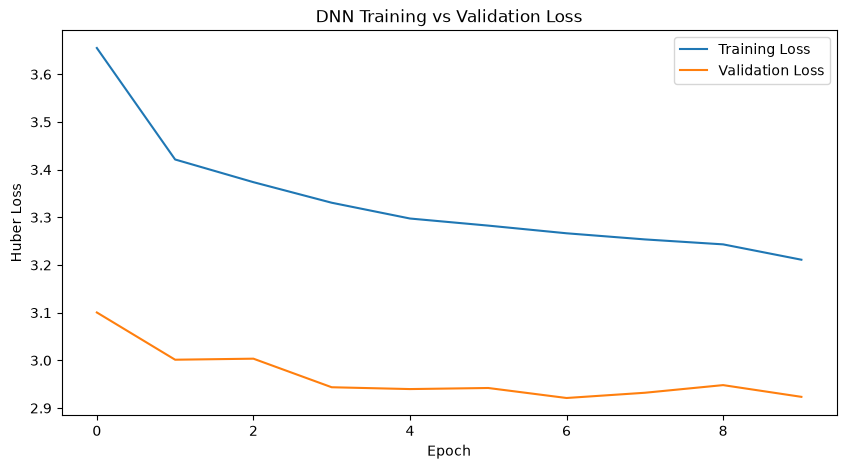

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_dnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_dnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")

plt.title(
    "DNN Training vs Validation Loss"
)

plt.legend()
plt.show()

### Five DNN architecture tuning experiments

Train DNN A through E once each using the same training and validation samples, categorical embeddings, preprocessing, seed, Adam learning rate, Huber loss, batch size, and epoch limit. Only the hidden-layer architecture changes. D and E extend the comparison with four hidden layers.

| Experiment | Hidden layers |
| --- | --- |
| DNN A | 128 → 64 |
| DNN B | 256 → 128 → 64 |
| DNN C | 512 → 256 → 128 |
| DNN D | 256 → 128 → 64 → 32 |
| DNN E | 512 → 256 → 128 → 64 |

Run the preprocessing, TensorFlow imports, `embedding_size`, `build_dnn`, and DNN input cells above before this section. Re-run the updated `build_dnn` cell if using an existing kernel. The earlier ANN and single-DNN training runs are optional for this section.

Rank by validation WAPE (lower is better). On this fixed validation sample, minimizing MAE also minimizes WAPE, so each run restores the epoch with the lowest validation MAE. Test data stays reserved for final evaluation after model selection. These are five architecture trials, not repeated-seed estimates of performance.


In [86]:
DNN_EXPERIMENTS = [
    {
        "name": "DNN A - Small",
        "hidden_units": (128, 64),
        "dropout_rate": 0.15,
        "learning_rate": 0.001,
    },
    {
        "name": "DNN B - Balanced",
        "hidden_units": (256, 128, 64),
        "dropout_rate": 0.20,
        "learning_rate": 0.001,
    },
    {
        "name": "DNN C - Wide",
        "hidden_units": (512, 256, 128),
        "dropout_rate": 0.25,
        "learning_rate": 0.0005,
    },
    {
        "name": "DNN D - Deep",
        "hidden_units": (256, 128, 64, 32),
        "dropout_rate": 0.20,
        "learning_rate": 0.0005,
    },
    {
        "name": "DNN E - Regularized",
        "hidden_units": (512, 256, 128, 64),
        "dropout_rate": 0.35,
        "learning_rate": 0.0005,
    },
]

In [87]:
def build_dnn(
    hidden_units=(256, 128, 64),
    dropout_rate=0.20,
):
    numerical_input = keras.Input(
        shape=(len(NUMERICAL_FEATURES),),
        name="numerical",
    )

    inputs = {
        "numerical": numerical_input
    }

    encoded_inputs = [
        numerical_input
    ]

    # Embeddings for categorical features
    for col in CATEGORICAL_FEATURES:

        vocab_size = len(category_maps[col]) + 1

        categorical_input = keras.Input(
            shape=(1,),
            dtype="int32",
            name=col,
        )

        inputs[col] = categorical_input

        embedding_dim = min(
            32,
            max(
                2,
                int(np.ceil(np.sqrt(vocab_size)))
            )
        )

        embedding = layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            name=f"{col}_embedding",
        )(categorical_input)

        embedding = layers.Flatten()(embedding)

        encoded_inputs.append(embedding)

    x = layers.Concatenate()(encoded_inputs)

    for units in hidden_units:

        x = layers.Dense(
            units,
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

    output = layers.Dense(
        1,
        activation="softplus",
        name="demand_7d",
    )(x)

    return keras.Model(
        inputs=inputs,
        outputs=output,
    )

In [88]:
from time import perf_counter

dnn_tuning_results = []
dnn_tuning_histories = {}

for experiment in DNN_EXPERIMENTS:

    name = experiment["name"]
    hidden_units = experiment["hidden_units"]
    dropout_rate = experiment["dropout_rate"]
    learning_rate = experiment["learning_rate"]

    run_id = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print(f"Hidden units: {hidden_units}")
    print(f"Dropout: {dropout_rate}")
    print(f"Learning rate: {learning_rate}")
    print("=" * 70)

    keras.backend.clear_session()

    keras.utils.set_random_seed(
        RANDOM_SEED
    )

    trial_model = build_dnn(
        hidden_units=hidden_units,
        dropout_rate=dropout_rate,
    )

    trial_model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        # Better for your skewed retail demand
        loss=keras.losses.Huber(),

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ],
    )

    parameter_count = trial_model.count_params()

    print(
        f"Parameters: {parameter_count:,}"
    )

    trial_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_mae",
            mode="min",
            patience=3,
            restore_best_weights=True,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),

        keras.callbacks.TerminateOnNaN(),
    ]

    started_at = perf_counter()

    trial_history = trial_model.fit(
        train_inputs,
        y_train,

        validation_data=(
            val_inputs,
            y_val
        ),

        epochs=25,
        batch_size=2048,

        callbacks=trial_callbacks,

        shuffle=True,
        verbose=1,
    )

    training_seconds = (
        perf_counter() - started_at
    )

    predictions = (
        trial_model.predict(
            val_inputs,
            batch_size=4096,
            verbose=0,
        )
        .reshape(-1)
    )

    metrics = regression_metrics(
        y_val,
        predictions
    )

    val_mae_history = np.asarray(
        trial_history.history["val_mae"]
    )

    model_path = (
        TUNING_MODEL_DIR
        / f"{run_id}.keras"
    )

    trial_model.save(model_path)

    dnn_tuning_histories[name] = (
        trial_history.history
    )

    dnn_tuning_results.append({
        "Model": name,
        "Hidden layers":
            " → ".join(
                map(str, hidden_units)
            ),
        "Dropout": dropout_rate,
        "Learning rate": learning_rate,
        "Parameters": parameter_count,
        "Epochs trained":
            len(val_mae_history),
        "Best epoch":
            int(
                np.argmin(
                    val_mae_history
                )
            ) + 1,
        "Training seconds":
            training_seconds,
        **metrics,
        "Model path":
            str(model_path),
    })

    print(
        f"\n{name} validation metrics:"
    )

    print(metrics)

    del (
        trial_model,
        trial_history,
        predictions,
        trial_callbacks,
    )


Training: DNN A - Small
Hidden units: (128, 64)
Dropout: 0.15
Learning rate: 0.001
Parameters: 115,520
Epoch 1/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 4.1863 - mae: 4.5685 - val_loss: 3.0762 - val_mae: 3.4907 - learning_rate: 0.0010
Epoch 2/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 3.4680 - mae: 3.8603 - val_loss: 3.0433 - val_mae: 3.4645 - learning_rate: 0.0010
Epoch 3/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 3.4204 - mae: 3.8160 - val_loss: 2.9924 - val_mae: 3.4141 - learning_rate: 0.0010
Epoch 4/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 3.3868 - mae: 3.7848 - val_loss: 2.9776 - val_mae: 3.3996 - learning_rate: 0.0010
Epoch 5/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 3.3603 - mae: 3.7594 - val_loss: 2.9556 - val_mae: 3.3804 - learning_rate: 0.0010
Epoch 6/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 3.3410 - mae: 3.7405 - val_loss: 2.9843 - val_mae: 3.4087 - learning_rate: 0.0010
Epoch 7/25
733/733 ━━━━━━━━━━━━━

In [89]:
dnn_tuning_results_df = (
    pd.DataFrame(
        dnn_tuning_results
    )
    .sort_values(
        ["WAPE", "RMSE", "MAE"]
    )
    .reset_index(drop=True)
)

display(
    dnn_tuning_results_df[
        [
            "Model",
            "Hidden layers",
            "Dropout",
            "Learning rate",
            "Parameters",
            "Best epoch",
            "MAE",
            "RMSE",
            "WAPE",
            "Training seconds",
        ]
    ]
)

,Model,Hidden layers,Dropout,Learning rate,Parameters,Best epoch,MAE,RMSE,WAPE,Training seconds
0,DNN D - Deep,256 → 128 → 64 → 32,0.2000,0.0005,160320,7,3.3532,7.7894,34.7256,317.7994
1,DNN B - Balanced,256 → 128 → 64,0.2000,0.0010,158144,4,3.3593,7.8094,34.7879,184.0160
2,DNN C - Wide,512 → 256 → 128,0.2500,0.0005,300480,3,3.3700,7.8564,34.8994,382.6129
3,DNN E - Regularized,512 → 256 → 128 → 64,0.3500,0.0005,308928,14,3.3702,7.9677,34.9013,957.6455
4,DNN A - Small,128 → 64,0.1500,0.0010,115520,8,3.3711,7.8605,34.9110,158.5079


In [90]:
### Save the tuning results and histories for future reference

import pickle

TUNING_RESULTS_FILE = REPORT_DIR / "results" / "dnn_tuning_results.csv"
TUNING_HISTORIES_FILE = REPORT_DIR / "results" / "dnn_tuning_histories.pkl"

TUNING_RESULTS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

dnn_tuning_results_df.to_csv(
    TUNING_RESULTS_FILE,
    index=False
)

with open(TUNING_HISTORIES_FILE, "wb") as f:
    pickle.dump(dnn_tuning_histories, f)

print(f"Saved results to: {TUNING_RESULTS_FILE}")
print(f"Saved histories to: {TUNING_HISTORIES_FILE}")

Saved results to: D:\Repos\ML-StockPredict\reports\results\dnn_tuning_results.csv
Saved histories to: D:\Repos\ML-StockPredict\reports\results\dnn_tuning_histories.pkl


### Compare Naive vs ANN vs DNN

Evaluate the seasonal-naive baseline, ANN, original DNN, and best tuned DNN on the same validation rows. Select the tuned model by lowest validation WAPE. Keep the original DNN in the comparison because tuning may not improve it. Lower MAE, RMSE, and WAPE are better; positive WAPE reduction means improvement over the naive baseline.

Run the ANN and original DNN training cells, validation preprocessing, and tuning results table first. This section predicts again using the trained models to avoid stale metric variables. It does not retrain models. These are validation results; confirm the selected model on the reserved test period before making a final performance claim.


In [91]:
# Use the same target values and row order for every model.
comparison_targets = val_df[TARGET].to_numpy(dtype="float32")
if not np.array_equal(comparison_targets, np.asarray(y_val).reshape(-1)):
    raise ValueError("Validation rows changed. Re-run validation preprocessing first.")

best_tuned_result = dnn_tuning_results_df.sort_values(
    ["WAPE", "RMSE", "MAE"], ignore_index=True,
).iloc[0]
best_tuned_dnn = keras.models.load_model(
    best_tuned_result["Model path"], compile=False,
)

comparison_predictions = {
    "Seasonal Naive": val_df["sales_sum_7"].to_numpy(),
    "ANN": ann.predict(X_num_val, batch_size=4096, verbose=0).reshape(-1),
    "DNN (original)": dnn.predict(val_inputs, batch_size=4096, verbose=0).reshape(-1),
    f"DNN (tuned: {best_tuned_result['Model']})": best_tuned_dnn.predict(
        val_inputs, batch_size=4096, verbose=0,
    ).reshape(-1),
}

comparison_rows = []
for model_name, model_predictions in comparison_predictions.items():
    model_predictions = np.asarray(model_predictions).reshape(-1)
    if model_predictions.shape != comparison_targets.shape:
        raise ValueError(f"{model_name}: predictions do not match validation rows.")
    if not np.isfinite(model_predictions).all():
        raise ValueError(f"{model_name}: predictions contain non-finite values.")
    comparison_rows.append({
        "Model": model_name,
        **regression_metrics(comparison_targets, model_predictions),
    })

model_comparison = pd.DataFrame(comparison_rows)
naive_wape = model_comparison.loc[
    model_comparison["Model"] == "Seasonal Naive", "WAPE",
].iloc[0]
model_comparison["WAPE reduction vs naive (%)"] = (
    (naive_wape - model_comparison["WAPE"]) / naive_wape * 100
    if np.isfinite(naive_wape) and naive_wape > 0
    else np.nan
)
model_comparison = model_comparison.sort_values(
    ["WAPE", "RMSE", "MAE"], ignore_index=True,
)
display(model_comparison.round(4))

comparison_path = REPORT_DIR / "results" / "naive_ann_dnn_comparison.csv"
comparison_path.parent.mkdir(parents=True, exist_ok=True)
model_comparison.to_csv(comparison_path, index=False)

winner = model_comparison.iloc[0]
print(f"Lowest validation WAPE: {winner['Model']} ({winner['WAPE']:.4f}%)")
print(f"Saved comparison: {comparison_path}")


,Model,MAE,RMSE,WAPE,WAPE reduction vs naive (%)
0,DNN (original),3.3449,7.6535,34.6389,15.7109
1,DNN (tuned: DNN D - Deep),3.3532,7.7894,34.7256,15.5000
2,ANN,3.3936,7.6667,35.1436,14.4828
3,Seasonal Naive,3.9683,8.7626,41.0953,0.0000


Lowest validation WAPE: DNN (original) (34.6389%)
Saved comparison: D:\Repos\ML-StockPredict\reports\results\naive_ann_dnn_comparison.csv


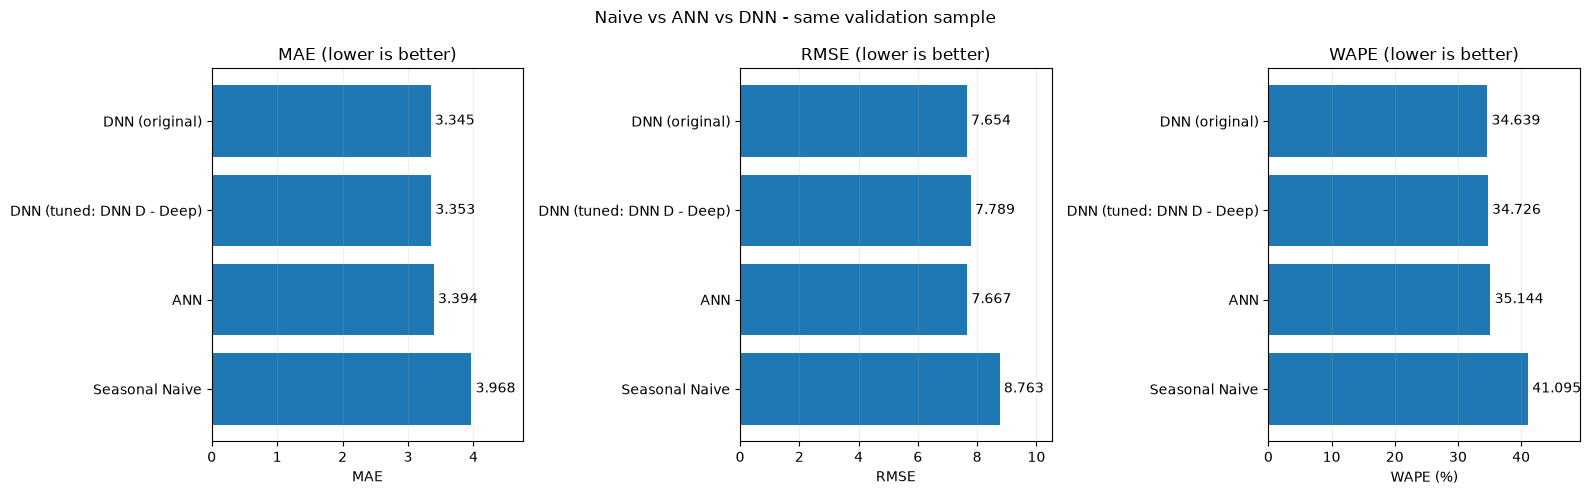

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["MAE", "RMSE", "WAPE"]):
    bars = ax.barh(model_comparison["Model"], model_comparison[metric])
    ax.invert_yaxis()
    ax.set_title(f"{metric} (lower is better)")
    ax.set_xlabel("WAPE (%)" if metric == "WAPE" else metric)
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.margins(x=0.20)
    ax.grid(axis="x", alpha=0.2)
fig.suptitle("Naive vs ANN vs DNN - same validation sample")
fig.tight_layout()
plt.show()


### Original DNN is the best performing model. so save it

In [103]:
from src.config import MODEL_DIR, REPORT_DIR
from src.models.artifacts import SavedForecaster

# The original DNN and fitted preprocessing were saved together earlier.
BEST_MODEL_BUNDLE = MODEL_DIR / "trained" / "best_model_20260912T132137305253Z"
final_test_forecaster = SavedForecaster(BEST_MODEL_BUNDLE)
if final_test_forecaster.metadata["model_name"] != "DNN (original)":
    raise ValueError("Expected the original DNN selected on validation.")

print("Saved model:", BEST_MODEL_BUNDLE / "model.keras")
print("Saved preprocessing:", BEST_MODEL_BUNDLE / "preprocessing.joblib")
print("Loaded original DNN for evaluation; no retraining is needed.")


Saved model: D:\Repos\ML-StockPredict\models\trained\best_model_20260912T132137305253Z\model.keras
Saved preprocessing: D:\Repos\ML-StockPredict\models\trained\best_model_20260912T132137305253Z\preprocessing.joblib
Loaded original DNN for evaluation; no retraining is needed.


### Final test evaluation

Use the existing `test_df` prepared earlier with `get_split(df, "test")`. In this notebook it contains **CA_1 only**, from **18 April to 15 May 2016**. Apply the saved original DNN and its fitted preprocessing to these rows, and compare against the naive baseline on the exact same targets. No model fitting or tuning occurs here.


In [104]:
import json
import numpy as np
import pandas as pd

# Load the saved forecaster if the model-loading cell was not executed.
if "final_test_forecaster" not in globals():
    from src.config import MODEL_DIR, REPORT_DIR
    from src.models.artifacts import SavedForecaster

    BEST_MODEL_BUNDLE = MODEL_DIR / "trained" / "best_model_20260912T132137305253Z"
    final_test_forecaster = SavedForecaster(BEST_MODEL_BUNDLE)

# Evaluate the test dataset already prepared earlier in this notebook.
if test_df.empty:
    raise ValueError("test_df is empty. Run the earlier test-split cell first.")
test_dates = pd.to_datetime(test_df["date"])
if not test_dates.between(TEST_START, TEST_END).all():
    raise ValueError("test_df contains rows outside TEST_START and TEST_END.")
validation_label_end = pd.Timestamp(final_test_forecaster.metadata["validation_end"]) + pd.Timedelta(days=7)
if test_dates.min() <= validation_label_end:
    raise ValueError("The test data overlaps the validation label period.")
if test_df.duplicated(["store_id", "item_id", "date"]).any():
    raise ValueError("test_df contains duplicate item-store forecast dates.")

y_test = test_df[TARGET].to_numpy(dtype="float64")
naive_test_predictions = test_df["sales_sum_7"].to_numpy(dtype="float64")
dnn_test_predictions = final_test_forecaster.predict(test_df)
if not np.isfinite(y_test).all() or not np.isfinite(naive_test_predictions).all():
    raise ValueError("Test targets and baseline predictions must be finite.")

test_comparison = pd.DataFrame([
    {"Model": "Seasonal Naive", **regression_metrics(y_test, naive_test_predictions)},
    {"Model": "Original DNN", **regression_metrics(y_test, dnn_test_predictions)},
])
naive_test_wape = test_comparison.loc[0, "WAPE"]
test_comparison["WAPE reduction vs naive (%)"] = (
    (naive_test_wape - test_comparison["WAPE"]) / naive_test_wape * 100
    if np.isfinite(naive_test_wape) and naive_test_wape > 0 else np.nan
)

print("Test stores:", ", ".join(sorted(test_df["store_id"].astype(str).unique())))
print(f"Test period: {test_dates.min():%Y-%m-%d} to {test_dates.max():%Y-%m-%d}")
print(f"Test rows: {len(test_df):,}")
display(test_comparison.round(4))

existing_test_predictions = test_df[["date", "store_id", "item_id", TARGET]].copy()
existing_test_predictions["naive_prediction"] = naive_test_predictions
existing_test_predictions["dnn_prediction"] = dnn_test_predictions
EXISTING_TEST_RESULTS = REPORT_DIR / "results" / "final_test_existing_split"
EXISTING_TEST_RESULTS.mkdir(parents=True, exist_ok=True)
test_comparison.to_csv(EXISTING_TEST_RESULTS / "test_comparison.csv", index=False)
existing_test_predictions.to_parquet(EXISTING_TEST_RESULTS / "test_predictions.parquet", index=False)
print("Saved this test_df evaluation to:", EXISTING_TEST_RESULTS)


Test stores: CA_1
Test period: 2016-04-18 to 2016-05-15
Test rows: 85,372


,Model,MAE,RMSE,WAPE,WAPE reduction vs naive (%)
0,Seasonal Naive,4.2373,7.9360,38.7286,0.0000
1,Original DNN,3.6411,7.3665,33.2794,14.0702


Saved this test_df evaluation to: D:\Repos\ML-StockPredict\reports\results\final_test_existing_split


### Visualize this test dataset

These charts use the same `test_df` evaluated immediately above. The scatter uses a fixed sample of up to 5,000 rows. Demand totals use every row and represent overlapping seven-day targets, grouped by forecast-origin date.

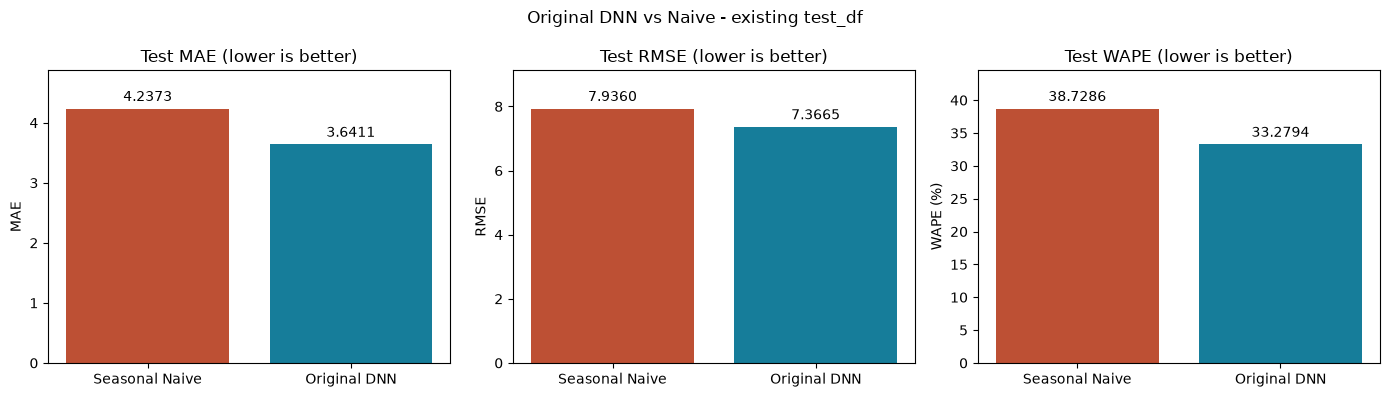

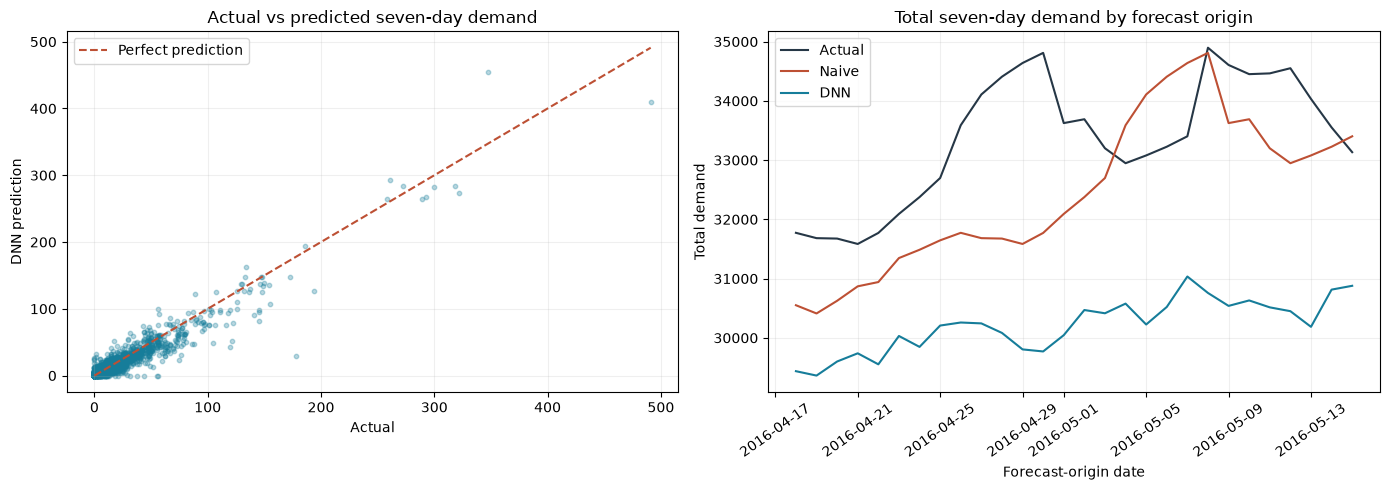

In [105]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "WAPE"]):
    bars = ax.bar(test_comparison["Model"], test_comparison[metric], color=["#bd5034", "#167d9a"])
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set(title=f"Test {metric} (lower is better)", ylabel="WAPE (%)" if metric == "WAPE" else metric)
    ax.margins(y=0.15)
fig.suptitle("Original DNN vs Naive - existing test_df")
fig.tight_layout()
fig.savefig(EXISTING_TEST_RESULTS / "test_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

plot_sample = existing_test_predictions.sample(n=min(5000, len(existing_test_predictions)), random_state=42)
test_daily_totals = existing_test_predictions.groupby("date", observed=True)[
    [TARGET, "naive_prediction", "dnn_prediction"]
].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(plot_sample[TARGET], plot_sample["dnn_prediction"], s=10, alpha=0.3, color="#167d9a")
axis_max = max(plot_sample[TARGET].max(), plot_sample["dnn_prediction"].max())
axes[0].plot([0, axis_max], [0, axis_max], "--", color="#bd5034", label="Perfect prediction")
axes[0].set(title="Actual vs predicted seven-day demand", xlabel="Actual", ylabel="DNN prediction")
axes[0].legend()
for column, label, color in [(TARGET, "Actual", "#263746"), ("naive_prediction", "Naive", "#bd5034"), ("dnn_prediction", "DNN", "#167d9a")]:
    axes[1].plot(test_daily_totals.index, test_daily_totals[column], label=label, color=color)
axes[1].set(title="Total seven-day demand by forecast origin", xlabel="Forecast-origin date", ylabel="Total demand")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(EXISTING_TEST_RESULTS / "test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
